In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s", datefmt="%H:%M:%S")

import numpy as np
import pandas as pd

from src.ml.data import get_train_val_test_splits
from src.ml.baseline import (
    train_vanilla, train_weighted, train_with_smote,
    evaluate, format_metrics_summary, save_model,
)

# Load splits (25K per family — same as Day 1)
splits = get_train_val_test_splits(sample_per_family=25_000)

X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]["is_attack"]
y_val   = splits["y_val"]["is_attack"]
y_test  = splits["y_test"]["is_attack"]

print(f"Train: {X_train.shape}, attacks={y_train.sum():,}, benign={(~y_train.astype(bool)).sum():,}")
print(f"Val:   {X_val.shape}, attacks={y_val.sum():,}, benign={(~y_val.astype(bool)).sum():,}")
print(f"Test:  {X_test.shape}, attacks={y_test.sum():,}, benign={(~y_test.astype(bool)).sum():,}")

19:46:16 | Loading labeled events (≤25000/family)
19:47:17 | Loaded 118,028 labeled rows
19:47:17 | Class distribution: {'Benign': 25000, 'DoS': 25000, 'DDoS': 25000, 'Reconnaissance': 25000, 'Brute Force': 13835, 'Web Attack': 2180, 'Botnet': 1966, 'Infiltration': 36, 'Exploit': 11}
19:47:18 | Splits: train=82,619, val=11,803, test=23,606


Train: (82619, 76), attacks=65,119, benign=17,500
Val:   (11803, 76), attacks=9,303, benign=2,500
Test:  (23606, 76), attacks=18,606, benign=5,000


In [2]:
# Variant 1: Vanilla
model_vanilla = train_vanilla(X_train, y_train)

# Variant 2: Class-weighted
model_weighted = train_weighted(X_train, y_train)

# Variant 3: SMOTE
model_smote = train_with_smote(X_train, y_train)

19:47:38 | Training vanilla Random Forest (no imbalance handling)
19:47:43 |   Trained in 4.8s
19:47:43 | Training Random Forest with class_weight='balanced'
19:47:47 |   Trained in 4.1s
19:47:47 | Applying SMOTE oversampling
c:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\capenv\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\capenv\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and 

In [3]:
metrics_vanilla  = evaluate(model_vanilla,  X_val, y_val, "Vanilla RF")
metrics_weighted = evaluate(model_weighted, X_val, y_val, "Class-Weighted RF")
metrics_smote    = evaluate(model_smote,    X_val, y_val, "SMOTE + RF")

summary = format_metrics_summary([metrics_vanilla, metrics_weighted, metrics_smote])
print("=== VALIDATION SET RESULTS ===")
print(summary.to_string(index=False))

=== VALIDATION SET RESULTS ===
            Model    AUC  Accuracy  Attack Precision  Attack Recall  Attack F1  Benign Recall
       Vanilla RF 0.9995    0.9982            0.9985         0.9992     0.9989         0.9944
Class-Weighted RF 0.9996    0.9985            0.9989         0.9991     0.9990         0.9960
       SMOTE + RF 0.9998    0.9981            0.9990         0.9985     0.9988         0.9964


In [4]:
print("=== CONFUSION MATRICES (Validation Set) ===")
print("Format: [[TN, FP], [FN, TP]]")
print(f"  TN = benign correctly identified")
print(f"  FP = benign flagged as attack (false alarm)")
print(f"  FN = attack missed (DANGEROUS)")
print(f"  TP = attack correctly caught\n")

for m in [metrics_vanilla, metrics_weighted, metrics_smote]:
    cm = np.array(m["confusion_matrix"])
    print(f"\n{m['label']}:")
    print(f"  {cm}")
    fn_rate = cm[1][0] / cm[1].sum()
    fp_rate = cm[0][1] / cm[0].sum()
    print(f"  False Negative Rate: {fn_rate:.2%} ({cm[1][0]:,} attacks missed)")
    print(f"  False Positive Rate: {fp_rate:.2%} ({cm[0][1]:,} false alarms)")

=== CONFUSION MATRICES (Validation Set) ===
Format: [[TN, FP], [FN, TP]]
  TN = benign correctly identified
  FP = benign flagged as attack (false alarm)
  FN = attack missed (DANGEROUS)
  TP = attack correctly caught


Vanilla RF:
  [[2486   14]
 [   7 9296]]
  False Negative Rate: 0.08% (7 attacks missed)
  False Positive Rate: 0.56% (14 false alarms)

Class-Weighted RF:
  [[2490   10]
 [   8 9295]]
  False Negative Rate: 0.09% (8 attacks missed)
  False Positive Rate: 0.40% (10 false alarms)

SMOTE + RF:
  [[2491    9]
 [  14 9289]]
  False Negative Rate: 0.15% (14 attacks missed)
  False Positive Rate: 0.36% (9 false alarms)


=== Top 20 Most Important Features ===
           feature  importance
init_win_bytes_fwd    0.076951
init_win_bytes_bwd    0.049789
  fwd_pkt_len_mean    0.049659
  pkt_len_variance    0.043505
   fwd_pkt_len_min    0.037336
   fwd_pkt_len_max    0.036656
   bwd_pkt_len_min    0.036474
       pkt_len_std    0.034872
   bwd_pkt_len_std    0.034652
  avg_fwd_seg_size    0.034499
  bwd_pkt_len_mean    0.028480
      pkt_len_mean    0.027374
 subflow_fwd_bytes    0.025638
 fwd_header_length    0.025088
       pkt_len_min    0.024492
  total_length_fwd    0.024250
      avg_pkt_size    0.023746
   bwd_pkt_len_max    0.022077
       pkt_len_max    0.021592
  avg_bwd_seg_size    0.020308


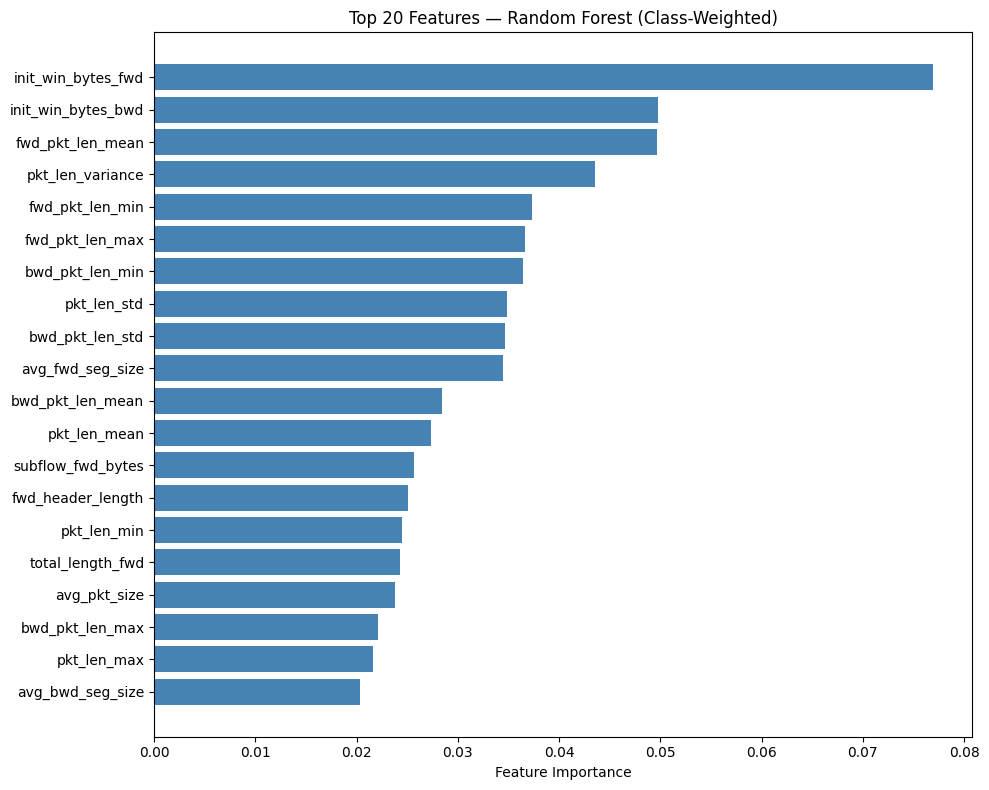

In [5]:
# Top features driving the best model's predictions
import matplotlib.pyplot as plt

# Pick whichever model performs best on validation
best_model = model_weighted  # tweak based on Cell 3 results

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False).head(20)

print("=== Top 20 Most Important Features ===")
print(importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importances["feature"], importances["importance"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 Features — Random Forest (Class-Weighted)")
plt.tight_layout()
plt.show()

In [6]:
# After choosing best model on validation, evaluate on TEST set (the final unbiased check)
best_label = "Class-Weighted RF"  # update based on Cell 3
best_model = model_weighted       # update based on Cell 3

test_metrics = evaluate(best_model, X_test, y_test, f"{best_label} (TEST SET)")

print("=== FINAL TEST SET PERFORMANCE ===")
for k, v in test_metrics.items():
    if k != "confusion_matrix":
        print(f"  {k:<22} {v}")

print(f"\nTest confusion matrix:")
print(np.array(test_metrics["confusion_matrix"]))

=== FINAL TEST SET PERFORMANCE ===
  label                  Class-Weighted RF (TEST SET)
  auc                    0.9996
  accuracy               0.9977
  benign_precision       0.994
  benign_recall          0.995
  benign_f1              0.9945
  attack_precision       0.9987
  attack_recall          0.9984
  attack_f1              0.9985
  n_samples              23606
  pred_time_sec          0.19

Test confusion matrix:
[[ 4975    25]
 [   30 18576]]


In [7]:
metadata = {
    "model_type": "RandomForest",
    "variant": "class_weighted",
    "n_estimators": 100,
    "max_depth": 20,
    "training_set_size": len(X_train),
    "training_samples_per_family": 25_000,
    "test_auc": test_metrics["auc"],
    "test_attack_f1": test_metrics["attack_f1"],
    "test_attack_recall": test_metrics["attack_recall"],
    "feature_count": X_train.shape[1],
}

path = save_model(best_model, name="rf_binary_v1", metadata=metadata)
print(f"\n✅ Saved to: {path}")
print(f"   Size: {path.stat().st_size / 1e6:.2f} MB")

19:52:49 | Model saved: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\models\rf_binary_v1.joblib



✅ Saved to: C:\Users\dunca\OneDrive\Documents\UON\SCS6104\Capstone\models\rf_binary_v1.joblib
   Size: 9.61 MB
